In [78]:
level = 2

In [ ]:
# TODO Double-check that loaded values are count data

In [79]:
import anndata
import pandas as pd
import urllib.request
import gzip
import os

# # Download the file
url = "https://datasets.cellxgene.cziscience.com/ff5a921e-6e6c-49f6-9412-ad9682d23307.h5ad"
# # Download the file
filename = os.path.basename(url)
# urllib.request.urlretrieve(url, filename)


# Create AnnData object from the DataFrame
adata = anndata.read_h5ad(filename, backed='r')



In [80]:
# This is one of multiple annotation layers in the dataset. 
adata.obs["full_cell_type_name"] = adata.obs["cell_type"].copy()


if level == 1:
    cell_type_dict = {
        'B': 'B cell',
        'CD34_HSPC': 'CD34-positive hematopoietic stem and progenitor cell',
        'DC': 'dendritic cell',
        'ILC': 'innate lymphoid cell',
        'Myeloid': 'myeloid cell',
        'NK': 'natural killer cell',
        'Plasma_Cell': 'plasma cell',
        'Platelet': 'platelet',
        'T': 'T cell',
    }
    level_name = "Annotation_Level1"
elif level == 2:
    cell_type_dict = {
        'B': 'B cell',
        'CD16+_NK': 'CD16-positive natural killer cell',
        'CD34_HSPC': 'CD34-positive hematopoietic stem and progenitor cell',
        'CD4+_T': 'CD4-positive T cell',
        'CD56+_NK': 'CD56-positive natural killer cell',
        'CD8+_T': 'CD8-positive T cell',
        'DC': 'dendritic cell',
        'ILC': 'innate lymphoid cell',
        'Monocyte': 'monocyte',
        'Myeloid': 'myeloid cell',
        'NK': 'natural killer cell',
        'Plasma_Cell': 'plasma cell',
        'Platelet': 'platelet',
        'T': 'T cell',
        'atypical_B': 'atypical B cell',
        'cDC': 'conventional dendritic cell',
        'dnT': 'double-negative T cell',
        'qdT': 'quadruple-negative T cell',
        'memory_B': 'memory B cell',
        'naive_B': 'naive B cell',
        'pDC': 'plasmacytoid dendritic cell',
    }
    level_name = "Annotation_Level2"
else:
    raise ValueError("level must be 1 or 2")


adata.obs["cell_type"] = adata.obs[level_name].map(cell_type_dict)


In [81]:
adata

AnnData object with n_obs × n_vars = 1265624 × 36406 backed at 'ff5a921e-6e6c-49f6-9412-ad9682d23307.h5ad'
    obs: 'mapped_reference_annotation', 'library_uuid', 'assay_ontology_term_id', 'library_starting_quantity', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'sample_uuid', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_derivation_process', 'donor_BMI_at_collection', 'tissue_type', 'suspension_derivation_process', 'suspension_enriched_cell_types', 'suspension_percent_cell_viability', 'suspension_uuid', 'suspension_type', 'donor_id', 'self_reported_ethnicity_ontology_term_id', 'donor_living_at_sample_collection', 'organism_ontology_term_id', 'disease_ontology_term_id', 'sex_ontology_term_id', 'nCount_RNA', 'nFeature_RNA', 'pMito', 'NODG', 'nUMI', 'Country', 'Annotation_Level1', 'Annotation_Level2', 'Annotation_Level3', 'Annotation_Level4', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'develo

In [82]:
sampled_indices = (
    adata.obs.groupby("cell_type", group_keys=False)
    .apply(lambda x: x.sample(min(1000, len(x)), random_state=0))
    .index
)

adata = adata[adata.obs.index.isin(sampled_indices)]

/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


In [83]:
adata=adata.to_memory()

<Axes: title={'center': 'Number of cells per cell type'}>

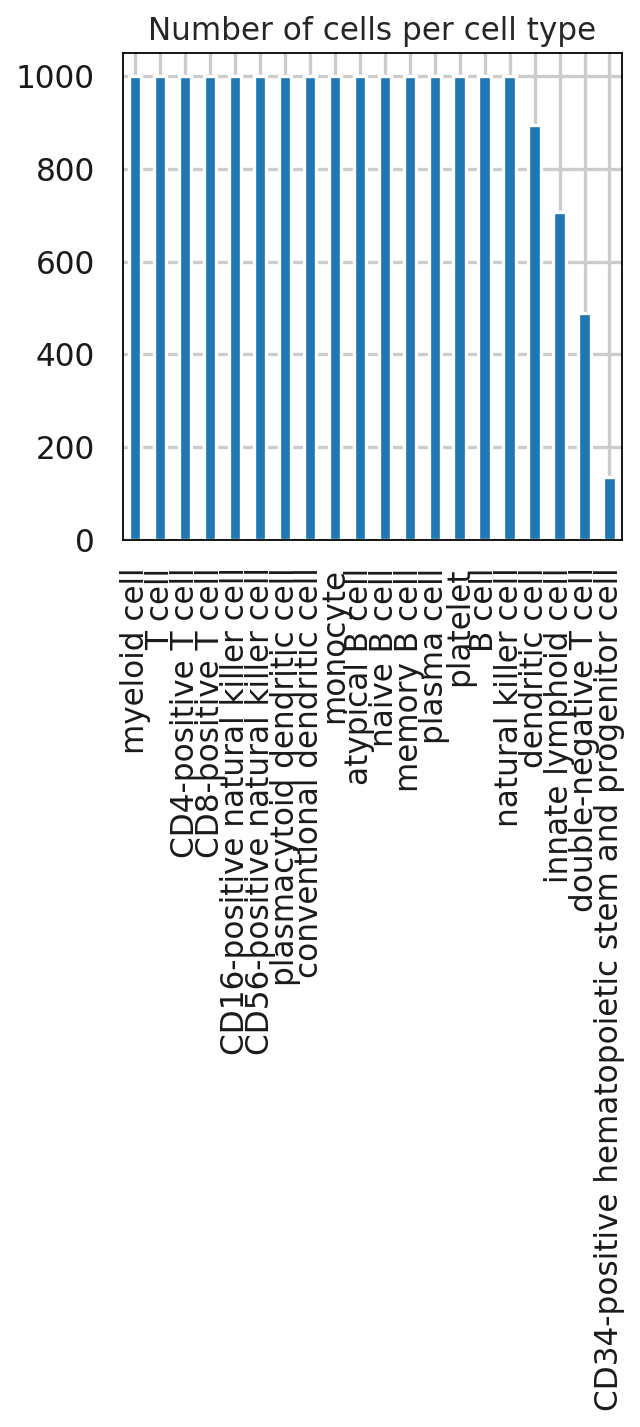

In [84]:
adata.obs["cell_type"].value_counts().plot(kind='bar', title="Number of cells per cell type")

In [85]:
import os
from pathlib import Path
import pandas as pd
import logging
import numpy as np
from collections import defaultdict
import copy
import matplotlib
import torch

from cellwhisperer.config import get_path
from cellwhisperer.utils.inference import score_modality_vs_texts
from cellwhisperer.validation.integration.functions import eval_scib_metrics
from cellwhisperer.utils.model_io import load_cellwhisperer_model

In [86]:
#### Parameters ####

ckpt_file_path="/msc/home/q56ppene/cellwhisperer/cellwhisperer/results/models/jointemb/cellwhisperer_clip_v1.ckpt"

SUFFIX_PREFIX_DICT={}
SUFFIX_PREFIX_DICT["cell_type"] = ("A sample of ", " from a healthy individual")

metadata_col = "cell_type"

average_by_class = False


In [87]:
#### Load model
# Load the cellwhisperer model
(
    pl_model_cellwhisperer,
    text_processor_cellwhisperer,
    cellwhisperer_transcriptome_processor,
) = load_cellwhisperer_model(model_path=ckpt_file_path, eval=True)
cellwhisperer_model  =  pl_model_cellwhisperer.model

In [88]:
#### Predict the labels using CellWhisperer
adata_no_nans = adata[
    ~(adata.obs[metadata_col].isna()) & ~(adata.obs[metadata_col] == "nan")
].copy()

labels = adata_no_nans.obs[metadata_col].unique().tolist()

if metadata_col in SUFFIX_PREFIX_DICT:
    prefix, suffix = SUFFIX_PREFIX_DICT[metadata_col]
    text_list=[f"{prefix}{x}{suffix}" for x in labels]
elif metadata_col not in SUFFIX_PREFIX_DICT:
    logging.warning(f"Label column {metadata_col} not found in SUFFIX_PREFIX_DICT, continuing without prefix/suffix")
    text_list = labels.copy()

In [89]:
import pandas as pd
import logging
import numpy as np
import copy
import matplotlib
import torch
import seaborn as sns
import scanpy as sc
import matplotlib.pyplot as plt
from cellwhisperer.validation.zero_shot.single_cell_annotation import (
    get_performance_metrics_transcriptome_vs_text
)

sc.set_figure_params(
    vector_friendly=True, dpi_save=500
)  # Makes PDFs of scatter plots much smaller in size but still high-quality


/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/scanpy/_settings.py:450: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  IPython.display.set_matplotlib_formats(*ipython_format)


In [90]:
#### Get classification performance metrics for cellwhisperer
    
correct_text_idx_per_transcriptome=[
        adata_no_nans.obs[metadata_col].unique().tolist().index(x)
        for x in adata_no_nans.obs[metadata_col].values
    ]
    
(
    performance_metrics,
    performance_metrics_per_label_df,
) = get_performance_metrics_transcriptome_vs_text(
    model=cellwhisperer_model,
    modality_input=adata_no_nans,
    text_list_or_text_embeds=text_list,#adata_no_nans.obs[metadata_col].unique().tolist(),
    average_mode=None,
    grouping_keys=None,
    transcriptome_processor=cellwhisperer_transcriptome_processor,
    batch_size=32,
    score_norm_method=None,
    correct_text_idx_per_transcriptome=correct_text_idx_per_transcriptome,
)


In [91]:
performance_metrics

{'precision_macroAvg': tensor(0.3328),
 'accuracy_macroAvg': tensor(0.2776),
 'f1_macroAvg': tensor(0.2199),
 'rocauc_macroAvg': tensor(0.9062),
 'recall_at_1_macroAvg': tensor(0.2776),
 'recall_at_5_macroAvg': tensor(0.7477),
 'recall_at_10_macroAvg': tensor(0.8589),
 'recall_at_50_macroAvg': tensor(nan)}

In [92]:
## Plot the confusion matrix

order=None

performance_metrics_per_label_df_wo_prefix_suffix = performance_metrics_per_label_df.copy()
performance_metrics_per_label_df_wo_prefix_suffix.index = [
    x.replace(prefix,"").replace(suffix,"")
    for x in performance_metrics_per_label_df.index.values
]
performance_metrics_per_label_df_wo_prefix_suffix.columns = [
    x.replace(prefix,"").replace(suffix,"")
    for x in performance_metrics_per_label_df.columns.values
]

In [93]:
f1s=pd.DataFrame(performance_metrics_per_label_df_wo_prefix_suffix.f1)

<Axes: title={'center': 'F1 scores for each cell type'}>

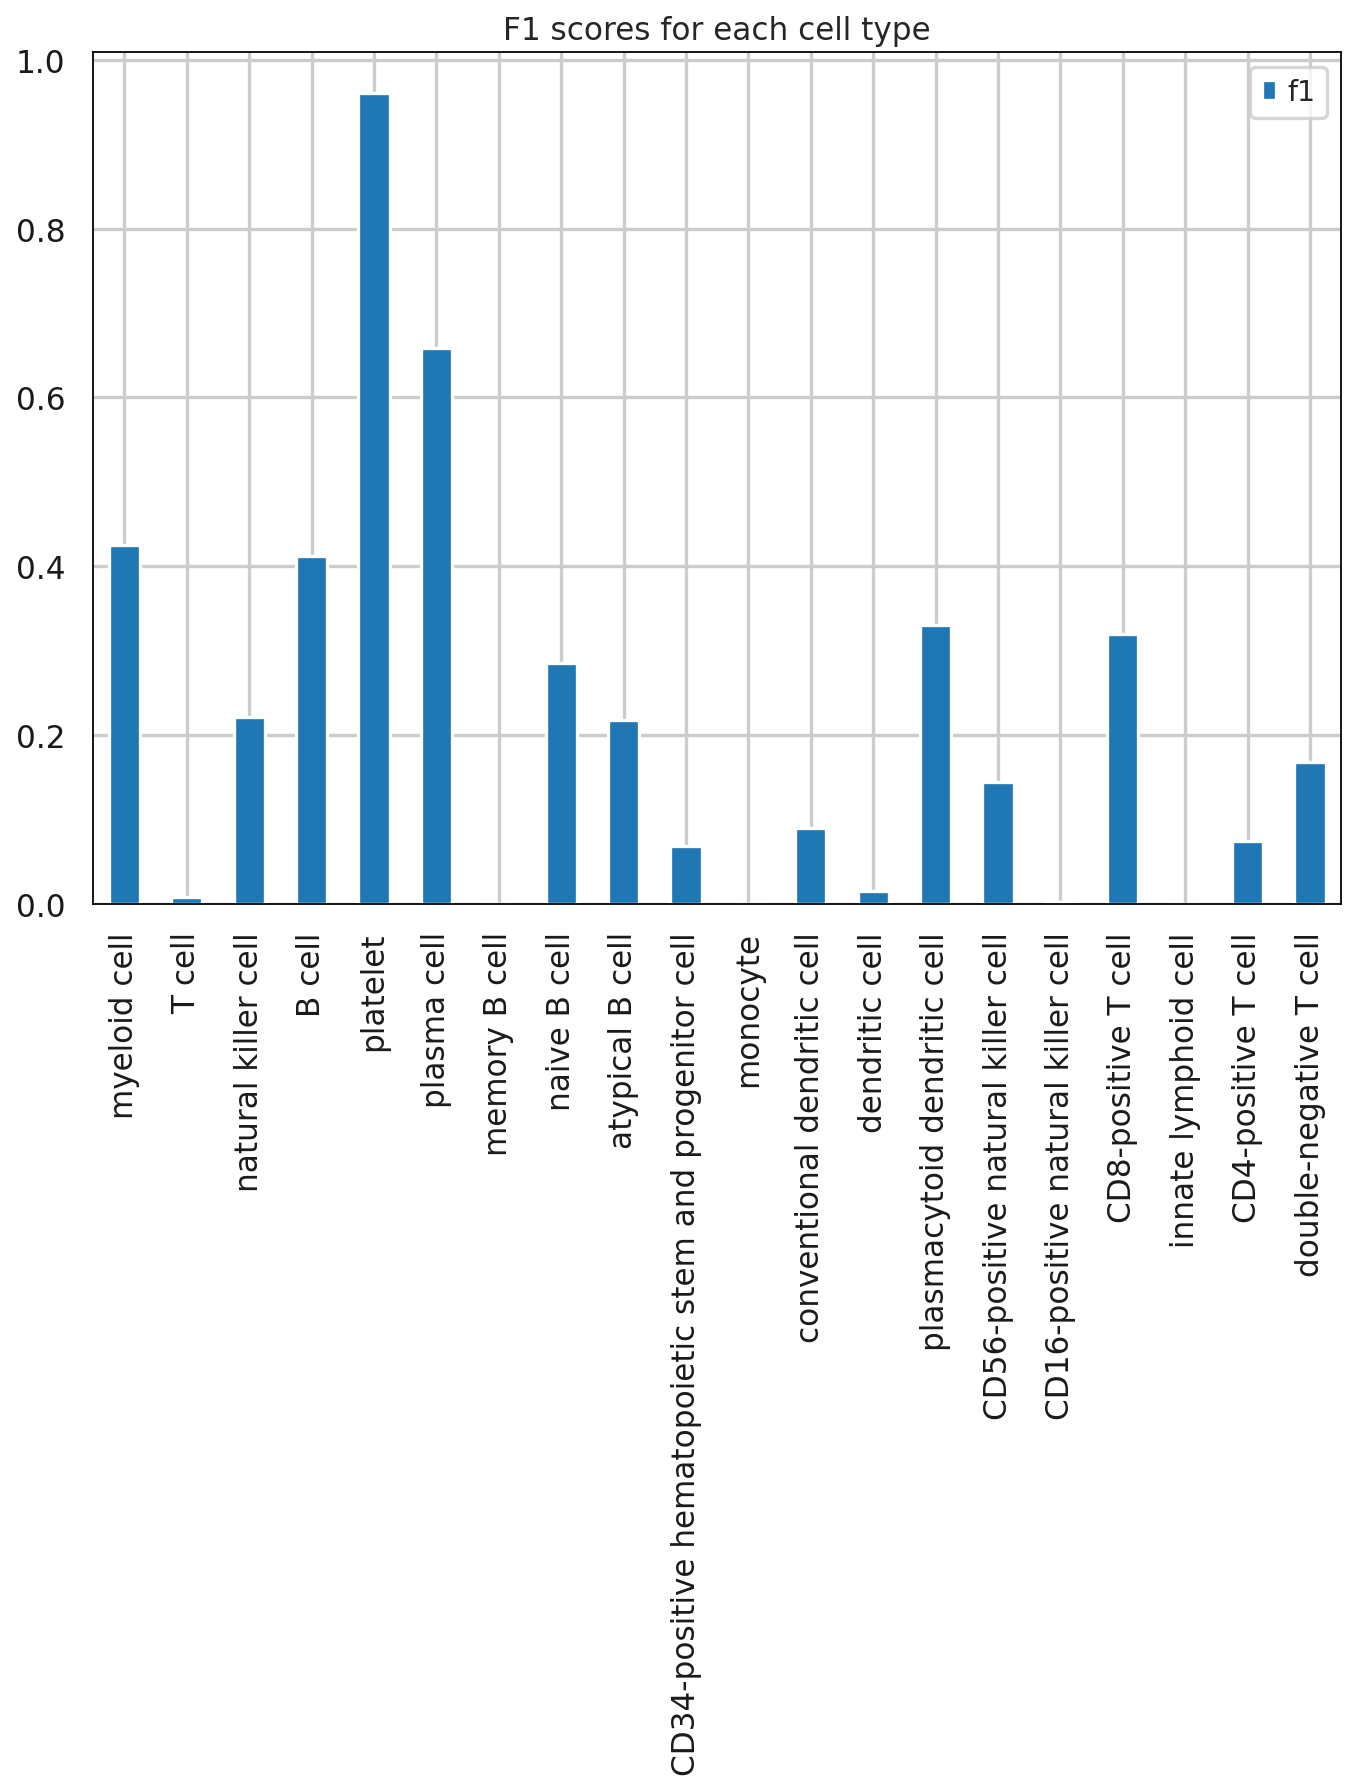

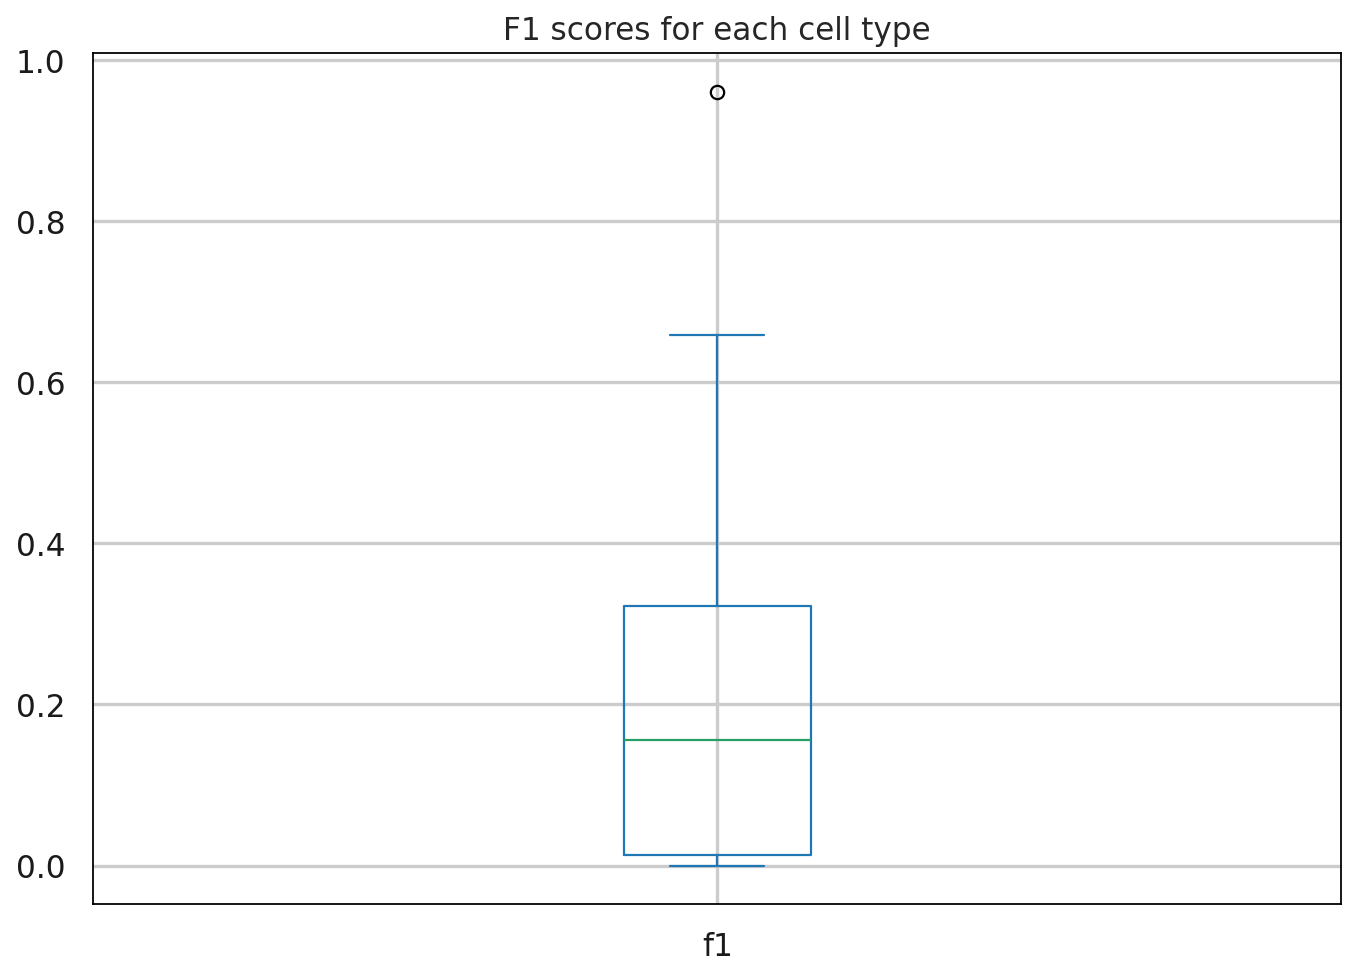

In [94]:
# plot a grouped bar chart
f1s.plot(kind='bar', title="F1 scores for each cell type", figsize=(10, 7))

# now, just treat each cell type as one data point and plot box plot
f1s.plot(kind='box', title="F1 scores for each cell type", figsize=(10, 7))


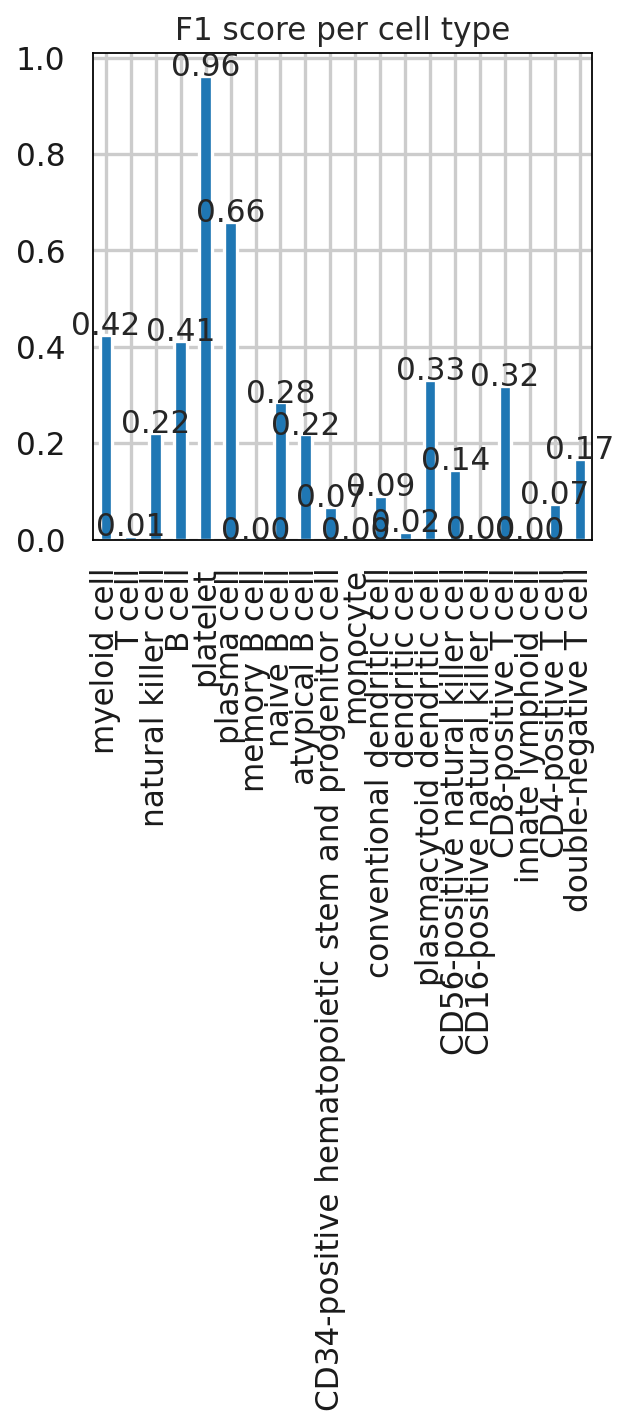

In [95]:
performance_metrics_per_label_df_wo_prefix_suffix.f1.plot(kind="bar", title="F1 score per cell type")
# label the scores above the bars
for i in range(len(performance_metrics_per_label_df_wo_prefix_suffix)):
    plt.text(
        x=i,
        y=performance_metrics_per_label_df_wo_prefix_suffix.f1[i],
        s=f"{performance_metrics_per_label_df_wo_prefix_suffix.f1[i]:.2f}",
        ha="center",
    )

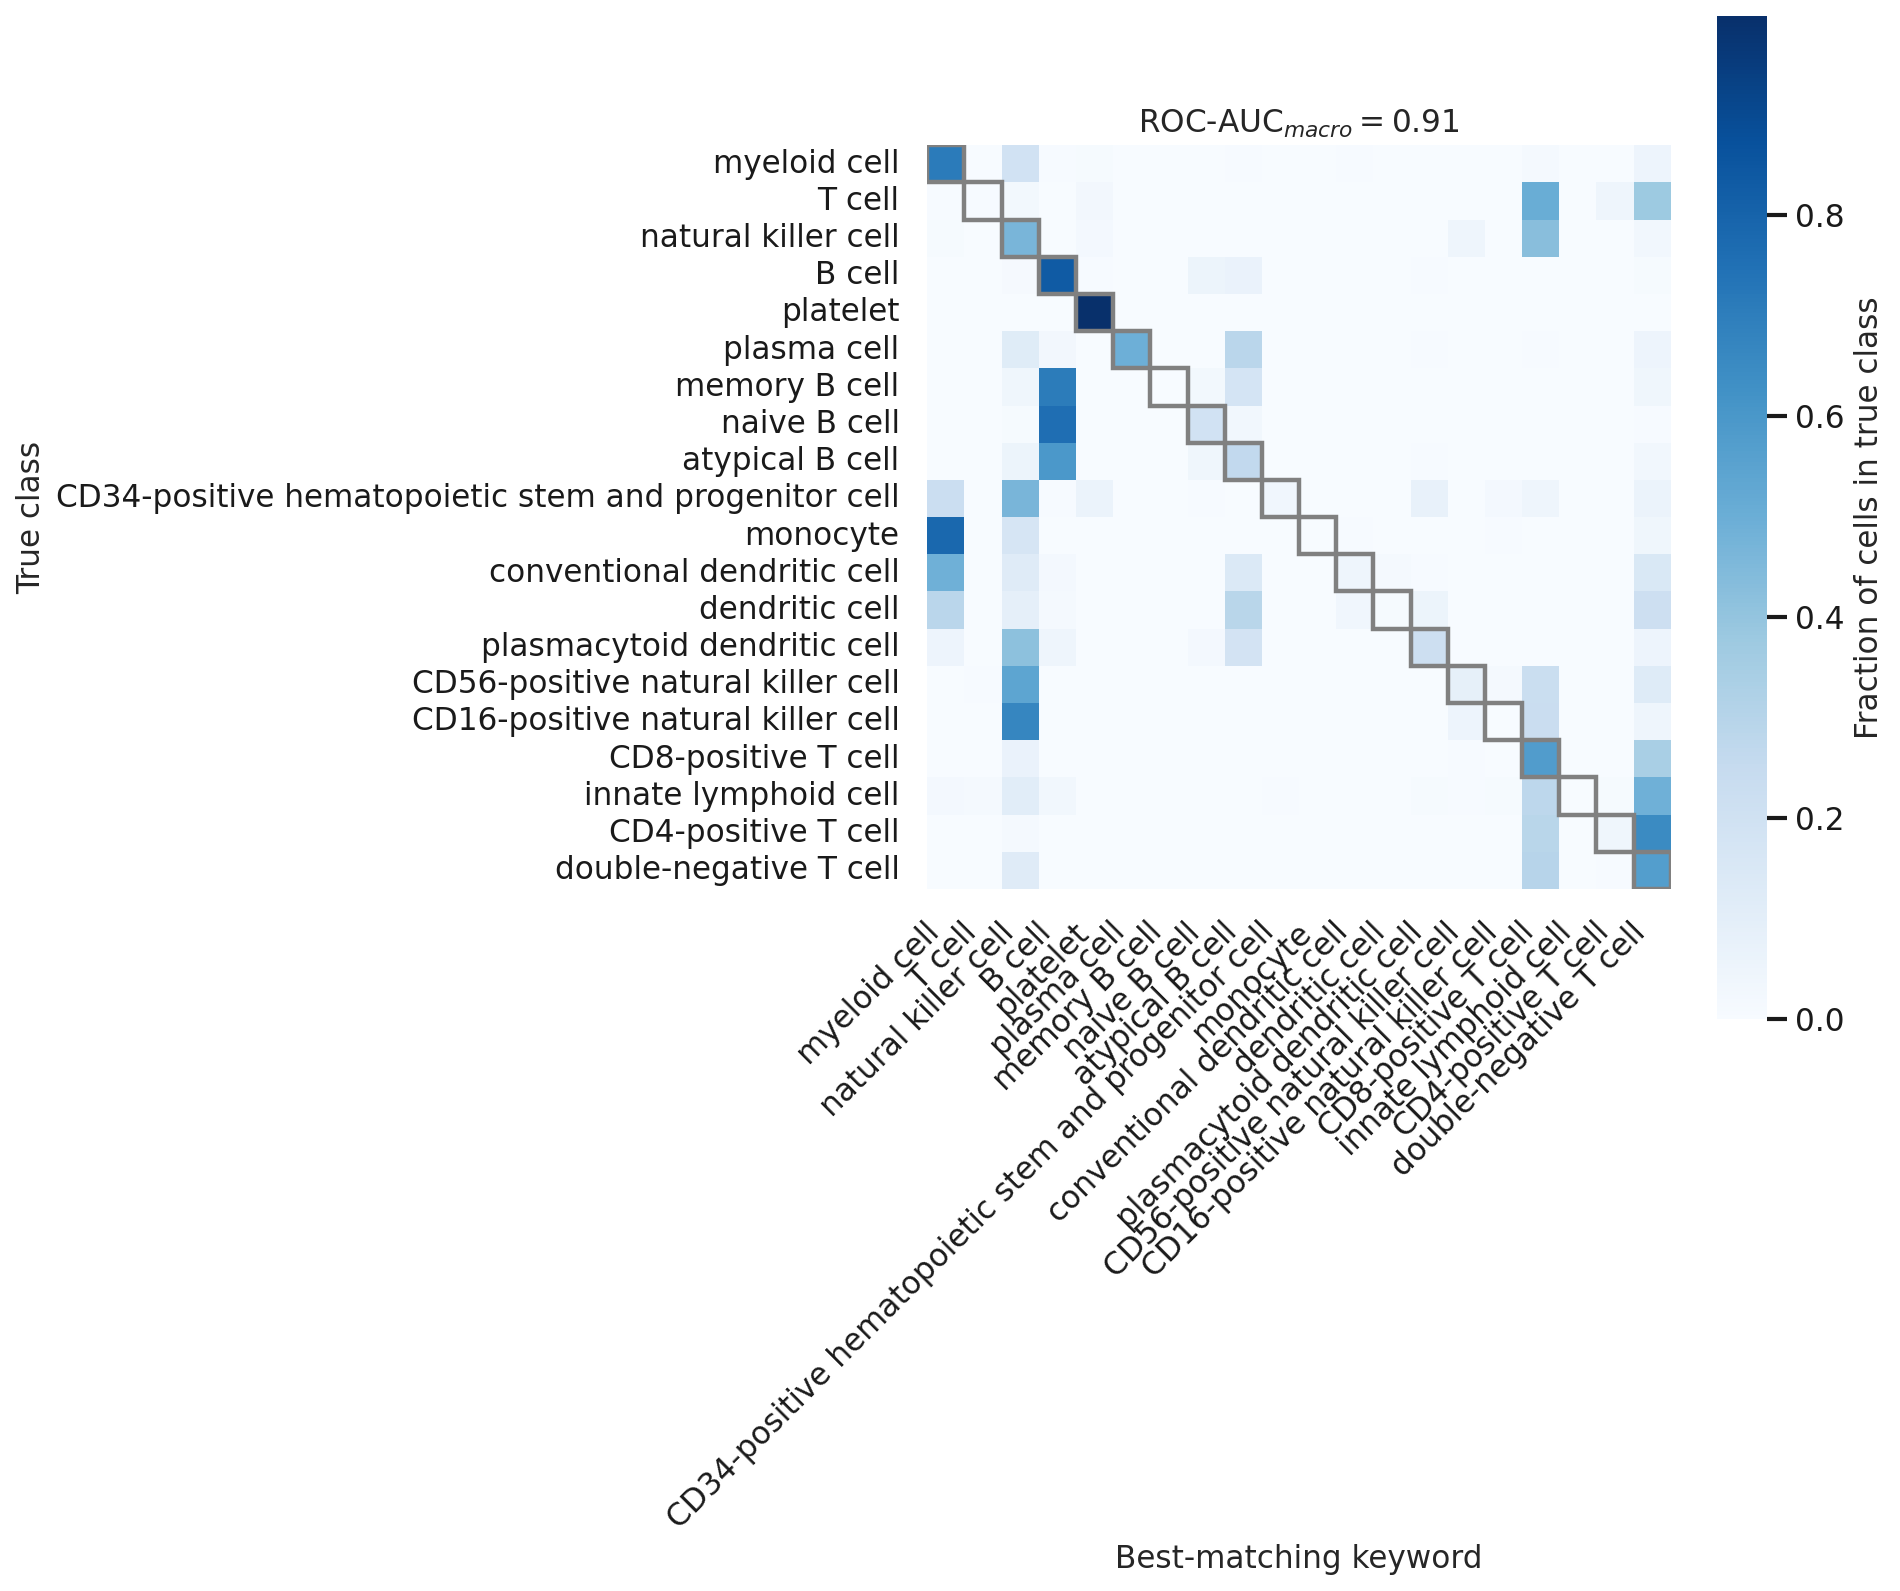

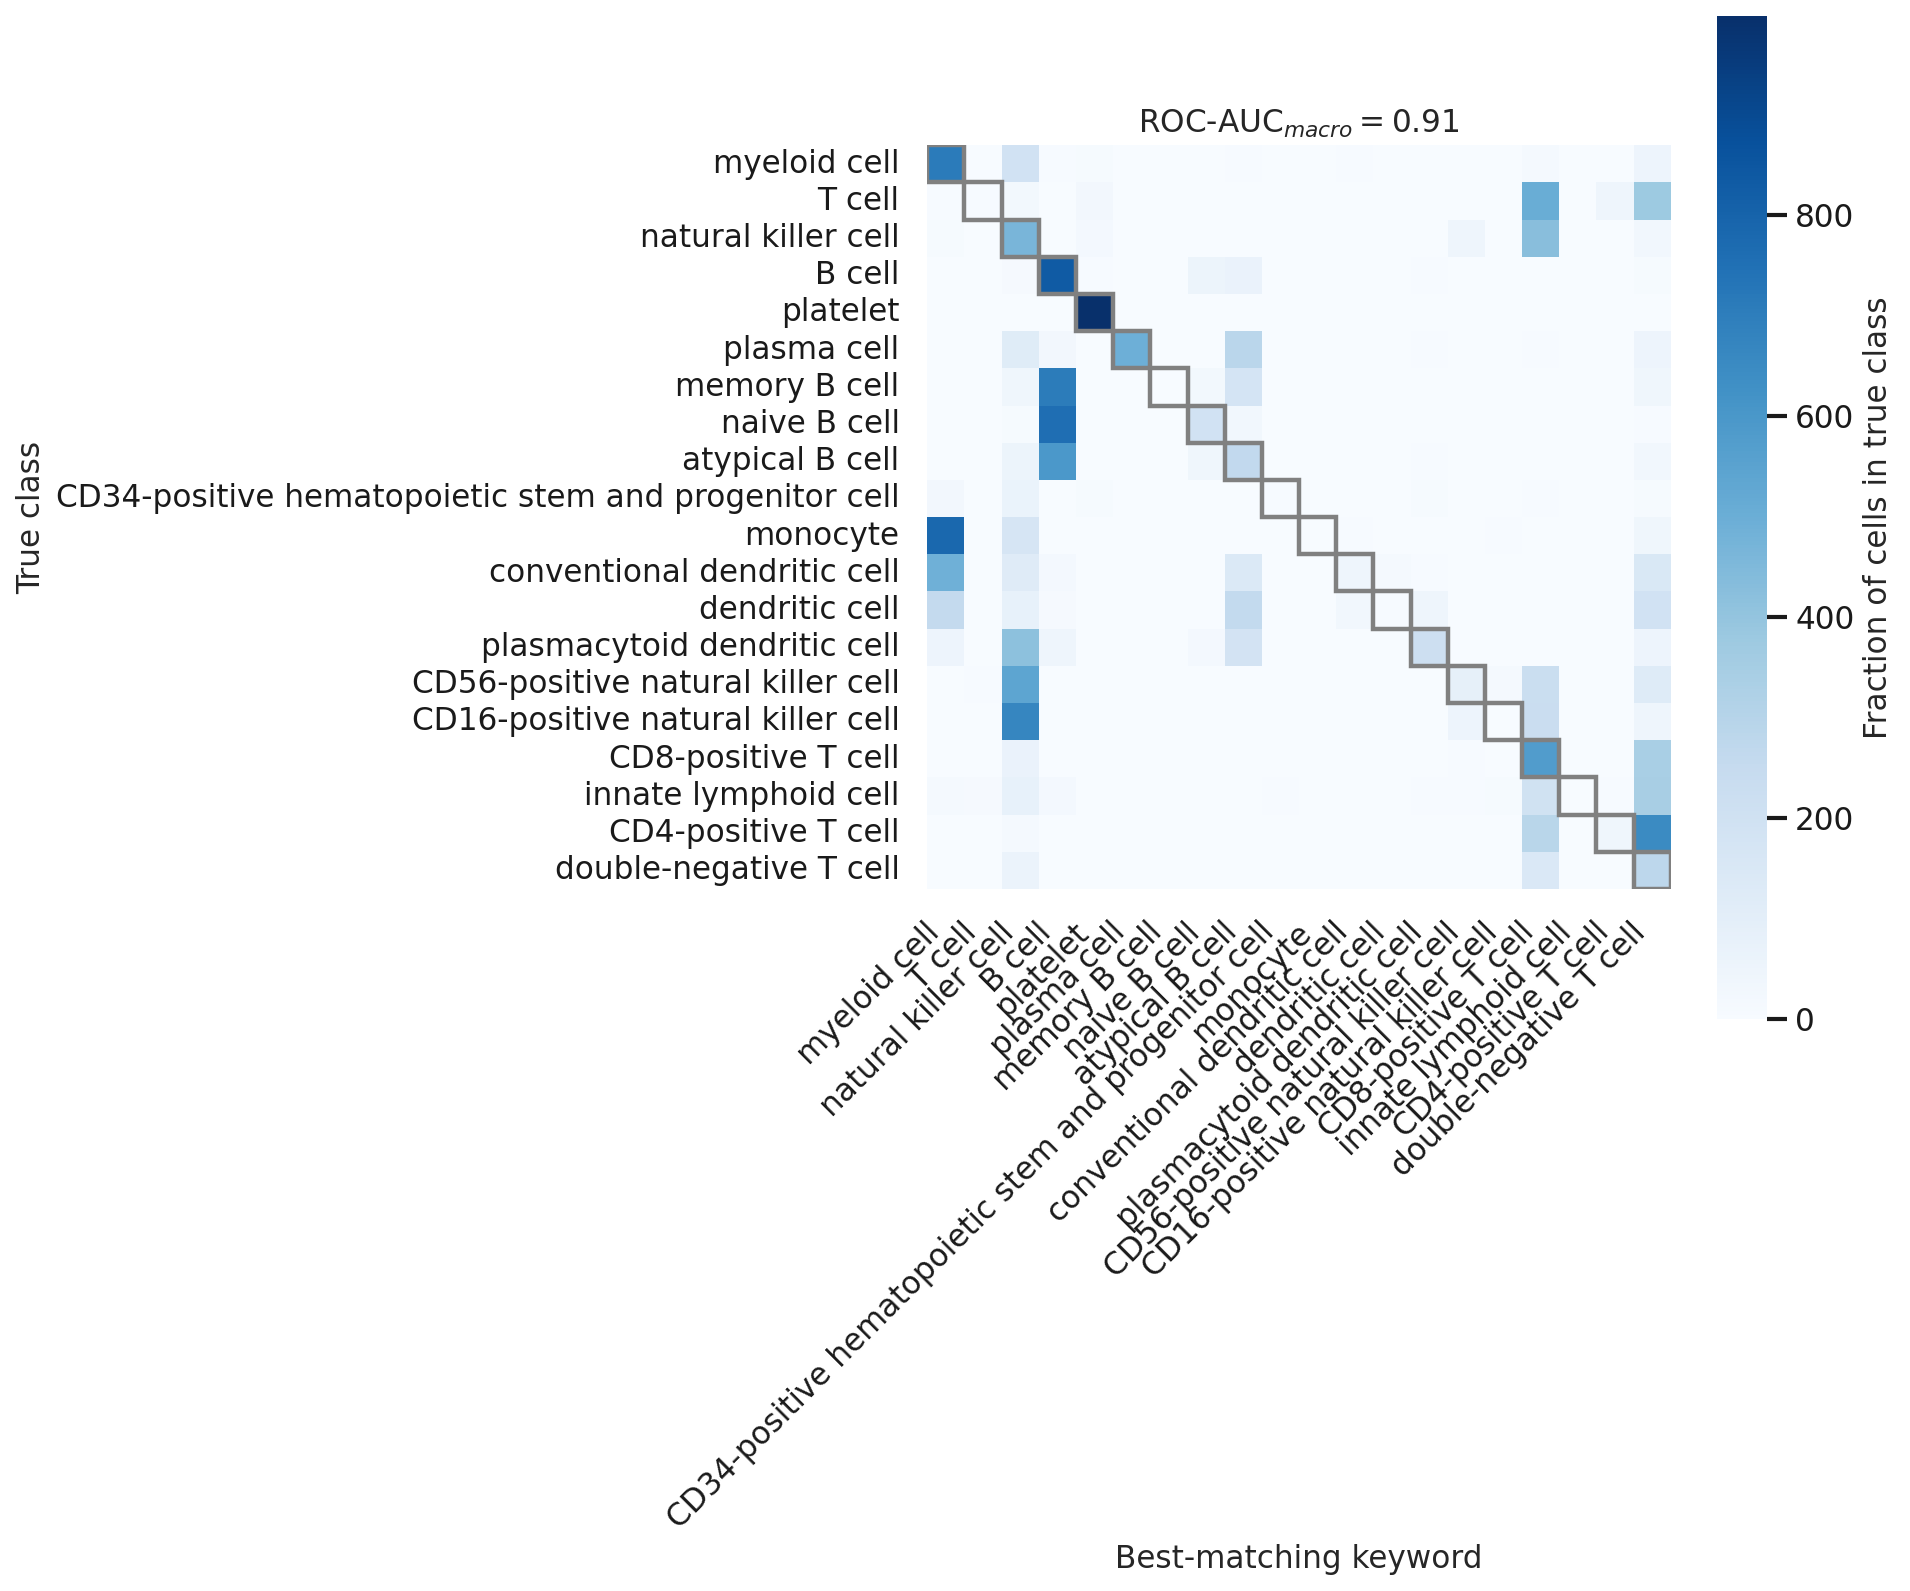

In [96]:
for normed in [True, False]:
    title = f"$\\text{{ROC-AUC}}_{{macro}}={round(float(performance_metrics['rocauc_macroAvg']),2)}$"
    performance_metrics_per_label_df=performance_metrics_per_label_df_wo_prefix_suffix

    confusion_matrix = performance_metrics_per_label_df[
        [
            x
            for x in performance_metrics_per_label_df
            if x.startswith("n_samples_predicted_as_")
        ]
    ]
    if normed:
        confusion_matrix = confusion_matrix.div(
            confusion_matrix.sum(axis=1), axis=0
        )
    confusion_matrix.columns = [
        x.replace("n_samples_predicted_as_", "") for x in confusion_matrix.columns
    ]
    if order is not None:
        confusion_matrix = confusion_matrix[order]
        confusion_matrix = confusion_matrix.loc[order]
    #confusion_matrix.to_excel(snakemake.output.confusion_matrix_table, index=True)

    plt.figure(figsize=(10, 10))
    sns.heatmap(
        confusion_matrix,
        cmap="Blues",
        annot=False,
        square=True,
        cbar_kws={"shrink": 0.7},
    )
    plt.yticks(
        [x + 0.5 for x in range(len(confusion_matrix.index))],
        confusion_matrix.index,
    )
    plt.xticks(
        [x + 0.5 for x in range(len(confusion_matrix.columns))],
        confusion_matrix.columns,
        rotation=45,
        ha="right",
    )
    plt.xlabel("Best-matching keyword")
    plt.ylabel("True class")
    plt.tight_layout()
    cbar = plt.gca().collections[0].colorbar
    cbar.set_label("Fraction of cells in true class")

    # mark the diagonal with boxes around the cells:
    for i in range(len(confusion_matrix.index)):
        for j in range(len(confusion_matrix.columns)):
            if i == j:
                plt.gca().add_patch(
                    plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="grey", lw=2)
                )

    plt.gcf().set_size_inches(
        max(15, len(confusion_matrix.index) // 2),
        max(15, len(confusion_matrix.index) // 2),
    )
    plt.title(title)

    #plt.savefig(snakemake.output.confusion_matrix_plot)
    plt.show()
    plt.close()
